In [1]:
import sys; sys.path.append('../..')
from abslithist import *
from abslithist.llms import *

In [2]:
LLM_STASH

Config,Param,Value
Path,Root Dir,/Users/ryan/github/abslithist/data/stash/llms
,Filename,data.db
Engine,Engine,pairtree
,Serializer,hashstash
,Compress,lz4
,B64,True
Stats,Len,188


In [3]:
def load_results(stash, model=DEFAULT_MODEL):
    id2data = defaultdict(list)
    for k,v in tqdm(stash.items(), total=len(stash)):
        if k['model'] != model:
            continue

        v = parse_json_str(v)
        if v:
            slice_txts = k['user_prompt'].split('#########\n\n')[1:]
            if len(slice_txts) != len(v):
                print(f"Warning: {k['text_id']} has {len(slice_txts)} slices but {len(v)} results")
                continue
            for txt,v_i in zip(slice_txts,v):
                v_i['slice_txt'] = txt
                v_i['concabs'] = score_psg(txt)
            id2data[k['text_id']].extend(v)
    return id2data
            

In [4]:
results = load_results(LLM_STASH)
# novel_results = results['Richardson.Pamela']
# novel_results.sort(key=lambda x: x['id'])
# novel_results[0]

  0%|          | 0/188 [00:00<?, ?it/s]

 46%|████▌     | 86/188 [00:00<00:00, 244.63it/s]

 89%|████████▉ | 168/188 [00:00<00:00, 226.97it/s]

Error parsing JSON: Expecting value: line 63 column 1 (char 2129)
Error parsing JSON: Expecting value: line 107 column 1 (char 3194)
Error parsing JSON: Expecting ',' delimiter: line 173 column 253 (char 5051)


100%|██████████| 188/188 [00:00<00:00, 210.82it/s]


In [5]:
def compile_dataframe(results, **metadata):
    """
    Compile slice-level JSON results into a flat dataframe.
    
    Returns two dataframes:
    - slices_df: one row per slice (slice-level annotations)
    - chars_df: one row per character-description per slice
      (with slice-level columns duplicated)
    """
    
    slice_rows = []
    char_rows = []
    
    for s in results:
        sid = s['id']
        slice_num = int(sid.split('_')[1])
        
        # Slice-level row
        slice_row = {
            **metadata,
            'slice_id': sid,
            'slice_num': slice_num,
            'slice_concabs': s.get('concabs', None),
            'summary': s.get('summary', ''),
            'narrative_mode': s.get('narrative_mode', ''),
            'concrete_abstract': s.get('concrete_abstract', None),
            'social_space': s.get('social_space', ''),
            'n_char_descriptions': len(s.get('character_descriptions', [])),
            'key_abstractions': s.get('key_abstractions', []),
            'key_concretions': s.get('key_concretions', []),
            'n_abstractions': len(s.get('key_abstractions', [])),
            'n_concretions': len(s.get('key_concretions', [])),
        }
        slice_rows.append(slice_row)
        
        # Character-level rows
        for desc in s.get('character_descriptions', []):
            # Normalize mode to always be a list
            mode = desc.get('mode', [])
            if isinstance(mode, str):
                mode = [mode]
            
            char_row = {
                # Slice-level info (duplicated)
                **metadata,
                'slice_id': sid,
                'slice_num': slice_num,
                'slice_concabs': s.get('concabs', None),
                'narrative_mode': s.get('narrative_mode', ''),
                'concrete_abstract': s.get('concrete_abstract', None),
                'social_space': s.get('social_space', ''),
                
                # Character-level info
                'character': desc.get('name', ''),
                'gender': desc.get('gender', 'unknown'),
                'class': desc.get('class', 'unknown'),
                'described_by': desc.get('described_by', ''),
                'passage': desc.get('passage', ''),
                'descriptors': desc.get('descriptors', []),
                'mode': mode,
                
                # Flattened mode booleans for easy filtering
                'mode_physical': 'physical' in mode,
                'mode_social': 'social' in mode,
                'mode_moral': 'moral' in mode,
                'mode_manner': 'manner' in mode,
                'mode_material': 'material' in mode,
                'mode_relational': 'relational' in mode,
                'mode_behavioral': 'behavioral' in mode,
                
                # Described-by categories
                'by_narrator': desc.get('described_by', '').startswith('narrator'),
                'by_other_char': desc.get('described_by', '').startswith('other_character'),
                'by_collective': desc.get('described_by', '').startswith('collective'),
            }
            char_rows.append(char_row)
    
    slices_df = pd.DataFrame(slice_rows)
    chars_df = pd.DataFrame(char_rows)
    
    return co_presence_ratio(slices_df), first_appearances(chars_df)


def first_appearances(chars_df):
    """
    For each character in each novel, find their first description.
    Everything after is a redescription.
    """
    chars_df = chars_df.copy()
    chars_df = chars_df.sort_values(['novel', 'character', 'slice_num'])
    chars_df['is_introduction'] = ~chars_df.duplicated(
        subset=['novel', 'character'], keep='first'
    )
    return chars_df


def co_presence_ratio(slices_df):
    """
    Compute abstract/concrete co-presence ratio per slice.
    High ratio = both registers loaded (allegorical).
    Low ratio = one register dominates.
    """
    df = slices_df.copy()
    df['co_presence'] = df.apply(
        lambda r: (
            min(r['n_abstractions'], r['n_concretions']) /
            max(r['n_abstractions'], r['n_concretions'])
            if max(r['n_abstractions'], r['n_concretions']) > 0
            else 0
        ),
        axis=1
    )
    return df


In [6]:
# Example: load and compile multiple novels

all_slices = []
all_chars = []

for novel,novel_results in results.items():
    slices_df, chars_df = compile_dataframe(
        novel_results, novel=novel
    )
    all_slices.append(slices_df)
    all_chars.append(chars_df)

slices = pd.concat(all_slices, ignore_index=True)
chars = pd.concat(all_chars, ignore_index=True)

# Add co-presence ratio
slices = co_presence_ratio(slices)

# Mark first appearances vs redescriptions
chars = first_appearances(chars)

# --------------------------------------------------------
# Quick analyses
# --------------------------------------------------------

# Average concreteness per novel
printm("### Average concreteness by novel")
display(slices.groupby('novel')['concrete_abstract'].mean().round(2))

# Narrative mode distribution per novel
printm("### Narrative mode distribution")
display(pd.crosstab(slices['novel'], slices['narrative_mode'], normalize='index').round(2))

# Social space distribution per novel
printm("### Social space distribution")
display(pd.crosstab(slices['novel'], slices['social_space'], normalize='index').round(2))

# Description mode by novel (% of character descriptions that are physical, moral, etc.)
printm("### Description mode by novel")
mode_cols = [c for c in chars.columns if c.startswith('mode_')]
display(chars.groupby('novel')[mode_cols].mean().round(2))

# Described-by source by novel
printm("### Description source by novel")
by_cols = ['by_narrator', 'by_other_char', 'by_collective']
display(chars.groupby('novel')[by_cols].mean().round(2))

# Description mode by class (across all novels)
printm("### Description mode by class")
display(chars.groupby('class')[mode_cols].mean().round(2).sort_values('mode_physical', ascending=False))

# Introductions only: mode by novel
intros = chars[chars['is_introduction']]
printm("### Introduction mode by novel")
display(intros.groupby('novel')[mode_cols].mean().round(2).sort_values('mode_physical', ascending=False))

# Co-presence ratio by novel
printm("### Co-presence ratio by novel")
display(slices.groupby('novel')['co_presence'].mean().round(2))

# Save
# slices.to_csv('results/slices_compiled.csv', index=False)
# chars.to_csv('results/chars_compiled.csv', index=False)
# print("\nSaved to results/slices_compiled.csv and results/chars_compiled.csv")

### Average concreteness by novel

novel
Anon.Lazarillo                                     4.95
Richardson.Pamela                                  3.48
Richardson.Pamela.Vol2                             3.00
chadwyck.Defoe.Moll_Flanders.1021                  3.78
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168    4.51
Name: concrete_abstract, dtype: float64

### Narrative mode distribution

narrative_mode,commentary,description,epistolary,reflection,scenic,summary
novel,,,,,,
Anon.Lazarillo,0.08,0.03,0.00,0.08,0.62,0.20
Richardson.Pamela,0.02,0.00,0.13,0.13,0.63,0.08
Richardson.Pamela.Vol2,0.10,0.02,0.35,0.10,0.34,0.08
chadwyck.Defoe.Moll_Flanders.1021,0.07,0.00,0.00,0.16,0.46,0.31
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,0.03,0.11,0.00,0.06,0.68,0.10


### Social space distribution

...

,mode_physical,mode_social,mode_moral,mode_manner,mode_material,mode_relational,mode_behavioral
class,,,,,,,
institutional,1.00,0.00,0.00,1.00,0.00,0.00,1.00
merchant,0.39,0.19,0.55,0.32,0.03,0.12,0.45
laboring_poor,0.38,0.28,0.55,0.18,0.04,0.14,0.40
unknown,0.35,0.20,0.59,0.20,0.06,0.18,0.47
professional,0.34,0.23,0.52,0.46,0.05,0.14,0.41
aristocracy,0.32,0.18,0.62,0.38,0.03,0.22,0.29
servant,0.32,0.15,0.71,0.24,0.02,0.15,0.30
clergy,0.25,0.20,0.65,0.30,0.02,0.14,0.31
gentry,0.24,0.15,0.73,0.30,0.04,0.18,0.37


### Introduction mode by novel

,mode_physical,mode_social,mode_moral,mode_manner,mode_material,mode_relational,mode_behavioral
novel,,,,,,,
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,0.49,0.24,0.46,0.28,0.08,0.19,0.41
Anon.Lazarillo,0.28,0.27,0.59,0.11,0.09,0.13,0.46
chadwyck.Defoe.Moll_Flanders.1021,0.22,0.36,0.62,0.28,0.07,0.14,0.47
Richardson.Pamela,0.20,0.24,0.72,0.19,0.04,0.11,0.39
Richardson.Pamela.Vol2,0.17,0.24,0.77,0.27,0.03,0.22,0.40


### Co-presence ratio by novel

novel
Anon.Lazarillo                                     0.70
Richardson.Pamela                                  0.80
Richardson.Pamela.Vol2                             0.80
chadwyck.Defoe.Moll_Flanders.1021                  0.86
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168    0.88
Name: co_presence, dtype: float64

In [8]:
tqdm.pandas()
chars['descriptors_concabs'] = chars['descriptors'].progress_apply(lambda x: score_psg('\n'.join(x)))

100%|██████████| 3784/3784 [00:00<00:00, 66959.37it/s]


In [20]:
novel_concabs = chars.groupby('novel').slice_concabs.mean().to_dict()
chars['novel_concabs'] = chars['novel'].map(novel_concabs)

In [21]:
odf=chars.groupby(['novel','class']).mean(numeric_only=True).sort_values('descriptors_concabs', ascending=False)[['novel_concabs','descriptors_concabs']]
odf['concabs_diff'] = odf['descriptors_concabs'] - odf['novel_concabs']
# odf.reset_index().sort_values(['novel','concabs_diff'], ascending=False).set_index(['novel','class']).round(2)
odf.sort_values('concabs_diff', ascending=False).round(2)


novel_concabs  \
novel                                           class                          
chadwyck.Defoe.Moll_Flanders.1021               aristocracy            -0.33   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 institutional          -0.06   
Richardson.Pamela                               merchant               -0.42   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 laboring_poor          -0.06   
Anon.Lazarillo                                  merchant                0.12   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 clergy                 -0.06   
                                                unknown                -0.06   
                                                servant                -0.06   
Richardson.Pamela.Vol2                          unknown                -0.57   
chadwyck.Defoe.Moll_Flanders.1021               servant                -0.33   
                                                laboring_poor          -0.33   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 merchant               -0.06   
Richardson.Pamela.Vol2                          gentry                 -0.57   
                                                aristocracy            -0.57   
Anon.Lazarillo                                  gentry                  0.12   
Richardson.Pamela.Vol2                          laboring_poor          -0.57   
Richardson.Pamela                               servant                -0.42   
Anon.Lazarillo                                  unknown                 0.12   
Richardson.Pamela.Vol2                          servant                -0.57   
Richardson.Pamela                               laboring_poor          -0.42   
chadwyck.Defoe.Moll_Flanders.1021               unknown                -0.33   
Anon.Lazarillo                                  laboring_poor           0.12   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 professional           -0.06   
Richardson.Pamela                               unknown                -0.42   
chadwyck.Defoe.Moll_Flanders.1021               gentry                 -0.33   
Richardson.Pamela                               gentry                 -0.42   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 aristocracy            -0.06   
Richardson.Pamela.Vol2                          professional           -0.57   
Richardson.Pamela                               professional           -0.42   
Anon.Lazarillo                                  clergy                  0.12   
                                                servant                 0.12   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 gentry                 -0.06   
chadwyck.Defoe.Moll_Flanders.1021               professional           -0.33   
                                                merchant               -0.33   
Richardson.Pamela                               aristocracy            -0.42   
Richardson.Pamela.Vol2                          clergy                 -0.57   
Richardson.Pamela                               clergy                 -0.42   
chadwyck.Defoe.Moll_Flanders.1021               clergy                 -0.33   
Anon.Lazarillo                                  professional            0.12   
Richardson.Pamela.Vol2                          merchant               -0.57   

                                                               descriptors_concabs  \
novel                                           class                                
chadwyck.Defoe.Moll_Flanders.1021               aristocracy                   0.41   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 institutional                 0.44   
Richardson.Pamela                               merchant                     -0.16   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 laboring_poor                 0.16   
Anon.Lazarillo                                  merchant                      0.31   
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168 clergy                        0.05   
              

In [22]:
chars['novel_character'] = chars['novel'] + '__' + chars['character']
chars_only_once = chars.novel_character.value_counts()
chars_only_once = chars_only_once[chars_only_once < 3].index.tolist()
chars_more_than_once = chars.query('~(novel_character in @chars_only_once)')
chars_more_than_once

,novel,slice_id,slice_num,slice_concabs,narrative_mode,concrete_abstract,social_space,character,gender,class,...,mode_material,mode_relational,mode_behavioral,by_narrator,by_other_char,by_collective,is_introduction,descriptors_concabs,novel_concabs,novel_character
3630,Anon.Lazarillo,slice_021,21,0.157327,summary,4,inter_social,Lazarillo,male,laboring_poor,...,False,False,True,False,True,False,True,0.266211,0.124179,Anon.Lazarillo__Lazarillo
3631,Anon.Lazarillo,slice_032,32,-0.175125,scenic,2,domestic_unfamiliar,Lazarillo,male,servant,...,False,True,False,False,True,False,False,-1.054882,0.124179,Anon.Lazarillo__Lazarillo
3632,Anon.Lazarillo,slice_035,35,0.043672,scenic,6,institutional,Lazarillo,male,servant,...,False,True,True,False,True,False,False,-0.162519,0.124179,Anon.Lazarillo__Lazarillo
3633,Anon.Lazarillo,slice_100,100,-0.206275,commentary,4,public_social,Lazarillo,male,laboring_poor,...,False,False,False,True,False,False,False,-0.329329,0.124179,Anon.Lazarillo__Lazarillo
3634,Anon.Lazarillo,slice_011,11,0.457496,scenic,6,inter_social,Lazaro,male,laboring_poor,...,False,False,False,False,True,False,True,0.072847,0.124179,Anon.Lazarillo__Lazaro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1486,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,slice_177,177,0.350340,scenic,6,inter_social,the servant,female,servant,...,False,True,False,False,True,False,False,0.729833,-0.064620,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168__the servant
1487,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,slice_178,178,0.206178,scenic,7,institutional,the servant,female,servant,...,True,False,False,True,False,False,False,1.160707,-0.064620,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168__the servant
1492,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,slice_502,502,0.272248,scenic,4,domestic_unfamiliar,the trooper,male,professional,...,False,False,False,True,False,False,True,0.865918,-0.064620,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168__the trooper
1493,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,slice_506,506,0.273806,scenic,5,domestic_unfamiliar,the trooper,male,professional,...,False,False,False,True,False,False,False,0.037145,-0.064620,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168__the trooper


In [23]:
chars_more_than_once.groupby(['novel','character']).descriptors_concabs.mean().sort_values(ascending=False).head(25)

novel                                            character                 
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168  the servant                   0.945270
                                                 Mrs. Smallweed                0.664189
                                                 Phil                          0.637041
                                                 Peepy                         0.517601
                                                 Nemo                          0.514390
                                                 Grandmother Smallweed         0.490711
Richardson.Pamela                                Mr. Jonathan                  0.488555
Anon.Lazarillo                                   Lazaro                        0.483073
                                                 the hermit                    0.470647
chadwyck.Dickens.Bleak_House_By_Charles_Di.1168  the trooper                   0.421739
                                            

In [24]:
pd.set_option('display.max_colwidth', 200)

In [25]:
chars_more_than_once_by_char = []
for (novel,char),df in chars_more_than_once.query('is_introduction==True').groupby(['novel','character']):
    descs = [x for d in df.descriptors for x in d]
    desc = '\n'.join(descs)
    score = score_psg(desc)
    chars_more_than_once_by_char.append({
        'novel':novel,
        'character':char,
        'class':df.iloc[0]['class'],
        'gender':df.iloc[0]['gender'],
        'descriptors_concabs':score,
        'novel_concabs':novel_concabs[novel],
        'concabs_diff':score - novel_concabs[novel],
        'descriptors':descs,
        'descriptors_num_words': len(desc.split())

    })
chars_more_than_once_by_char = pd.DataFrame(chars_more_than_once_by_char)
chars_more_than_once_by_char.sort_values('concabs_diff', ascending=False).round(2).query('descriptors_num_words >= 10').head(10)

,novel,character,class,gender,descriptors_concabs,novel_concabs,concabs_diff,descriptors,descriptors_num_words
95,chadwyck.Defoe.Moll_Flanders.1021,my Lancashire Husband,gentry,male,1.04,-0.33,1.37,"[known by his Cloaths, known by his Horse, known by his Face]",12
134,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Miss Jellyby,gentry,female,1.15,-0.06,1.22,"[shivering, with a broken candle in a broken candlestick, with an egg-cup]",12
147,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Mr. Krook,merchant,male,1.07,-0.06,1.14,"[standing at his shop-door, in his spectacles, looking after us, with his cat upon his shoulder]",16
174,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Phil,laboring_poor,male,1.02,-0.06,1.09,"[little grotesque man, large head, dressed something like a gunsmith, green baize apron and cap, face and hands are dirty with gunpowder, begrimed with the loading of guns, face all crushed togeth...",45
64,Richardson.Pamela.Vol2,Pamela and Mr. B.,gentry,unknown,0.43,-0.57,1.00,"[a fine instance, like the first pair before the Fall]",10
195,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,the trooper,professional,male,0.87,-0.06,0.93,"[square chest, angrily, his face fires and flushes all over]",10
118,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Grandmother Smallweed,merchant,female,0.85,-0.06,0.91,"[mumbling, shaking her head, screeches, like a horrible old parrot without any plumage]",13
166,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Mrs. Rouncewell,servant,female,0.80,-0.06,0.86,"[fine old lady, handsome, stately, wonderfully neat, has such a back, such a stomacher, rather deaf, Weather affects her little]",20
17,Richardson.Pamela,Mr. Colbrand,servant,male,0.43,-0.42,0.85,"[put on one of his deadly fierce looks, with his huge strides]",12
18,Richardson.Pamela,Mr. Jonathan,servant,male,0.43,-0.42,0.84,"[a very grave good sort of old man, with his hair as white as silver, an honest worthy man]",19


In [26]:
chars_more_than_once_by_char.sort_values('concabs_diff', ascending=True).round(2).query('descriptors_num_words >= 10').head(10)

,novel,character,class,gender,descriptors_concabs,novel_concabs,concabs_diff,descriptors,descriptors_num_words
154,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Mr. Vholes,professional,male,-1.39,-0.06,-1.32,"[has common sense, has responsibility, has respectability, an exemplary man]",10
128,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Lady Dedlock,aristocracy,female,-1.10,-0.06,-1.03,"[supposes herself to be an inscrutable Being, out of the reach and ken of ordinary mortals, has weaknesses, prejudices, follies, haughtinesses, and caprices, her moral nature is accurately calcula...",31
163,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Mrs. Jellyby,gentry,female,-1.01,-0.06,-0.94,"[a lady of very remarkable strength of character, devotes herself entirely to the public]",14
124,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,John Jarndyce,gentry,male,-0.97,-0.06,-0.90,"[could never bear acknowledgments for any kindness, would resort to the most singular expedients and evasions, would even run away]",20
86,chadwyck.Defoe.Moll_Flanders.1021,The elder brother,gentry,male,-1.12,-0.33,-0.79,"[offered no manner of Rudness, professing a great deal of Love, meant no ill to me]",16
165,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Mrs. Rachael,servant,female,-0.83,-0.06,-0.76,"[our only servant, another very good woman, austere to me]",10
122,chadwyck.Dickens.Bleak_House_By_Charles_Di.1168,Harold Skimpole,professional,male,-0.81,-0.06,-0.75,"[a child, grown up, as old as I am, simplicity, freshness, enthusiasm, a fine guileless inaptitude for all worldly affairs, a perfect child, a musical man, an Amateur, an Artist, a man of attainme...",51
87,chadwyck.Defoe.Moll_Flanders.1021,The gentleman,gentry,male,-1.06,-0.33,-0.74,"[a compleat Gentleman, his Company was agreeable, made no Professions... but of an extraordinary Respect, had such an Opinion of my Virtue]",22
98,chadwyck.Defoe.Moll_Flanders.1021,the Captain,professional,male,-0.96,-0.33,-0.63,"[made no scruple to affirm, knew not one Word of the Matter, thought no Harm, really believ'd it to be so]",21
78,chadwyck.Defoe.Moll_Flanders.1021,He,professional,male,-0.94,-0.33,-0.61,"[shook his Head, with some Concern, had a Wife, and no Wife, sincere disinterested Honesty, disinterestedly concern'd for my safety]",20


In [27]:
chars_more_than_once_by_char.groupby(['class']).agg({
    'descriptors_concabs':'mean',
    'novel_concabs':'mean',
    'concabs_diff':'mean',
    'descriptors_num_words':'sum',
}).sort_values('concabs_diff', ascending=False)

,descriptors_concabs,novel_concabs,concabs_diff,descriptors_num_words
class,,,,
merchant,0.236649,-0.084832,0.321480,271
laboring_poor,0.038514,-0.188916,0.227430,203
unknown,-0.115192,-0.178745,0.063553,175
servant,-0.268713,-0.306521,0.047112,299
gentry,-0.305935,-0.312440,0.006505,923
clergy,-0.260328,-0.204628,-0.055700,82
professional,-0.255005,-0.150643,-0.104362,471
aristocracy,-0.635935,-0.356058,-0.279877,267


In [28]:
# chars_more_than_once_by_char.query('descriptors_num_words >= 25').sort_values('descriptors_concabs', ascending=False)[['novel','character','descriptors_concabs','descriptors','descriptors_num_words']].dropna().head(25)

In [95]:
pamela1_slices = slices[slices.novel == 'Richardson.Pamela']
pamela2_slices = slices[slices.novel == 'Richardson.Pamela.Vol2']
# pamela2_slices['slice_num'] = pamela2_slices['slice_num'] + len(pamela1_slices)
pamela2_slices['slice_num'] = pamela2_slices['slice_num'] + pamela1_slices.slice_num.max()
pamela_slices = pd.concat([pamela1_slices, pamela2_slices])
pamela_slices

,novel,slice_id,slice_num,slice_concabs,summary,narrative_mode,concrete_abstract,social_space,n_char_descriptions,key_abstractions,key_concretions,n_abstractions,n_concretions,co_presence
1088,Richardson.Pamela,slice_200,200,-0.459499,"Mr. B promises to make amends to Pamela but then flies into a rage when she asks to return to her parents, ordering her out of his sight and preparing his chariot to send her away.",scenic,4,domestic_unfamiliar,1,"[danger, distress, opinion, amends, honour, passion, folly, wrath, art, lordliness, will]","[papers, pocket, foot, alley, closet, dinner, chariot]",11,7,0.636364
1089,Richardson.Pamela,slice_201,201,-0.290625,"Pamela reflects on the pride of the upper class, is told by Mrs. Jewkes that she is being sent home immediately, and prepares to leave while expressing her fear and sorrow.",scenic,5,domestic_unfamiliar,1,"[blessings, pride of birth, pride of fortune, disquiets, design, resolution]","[house, father, mother, housekeeper, papers, writings, bosom, chariot, horses]",6,9,0.666667
1090,Richardson.Pamela,slice_202,202,-0.148224,"After a final sarcastic exchange with Mrs. Jewkes, Pamela overhears Mr. B defend her virtue and refuse to let her be harmed, which moves her so deeply that she falls to her knees to thank him befo...",scenic,6,domestic_unfamiliar,3,"[spirit, civilities, trouble, proof, virtue, pride, goodness, displeasure]","[guineas, hand, window, portmanteau, handkerchief, paper, ink, pens, parlour, door, knees]",8,11,0.727273
1091,Richardson.Pamela,slice_203,203,-0.317333,"As she rides away in the chariot, Pamela reflects on her confusing feelings of regret at leaving, Mr. B's contradictory nature, and his surprising goodness in defending her against Mrs. Jewkes.",reflection,3,inter_social,2,"[bondage, impulse, abstinence, prayer, mortification, goodness, fortune, respect, kindness, hate]","[onions, garlick, heart, chariot, hat, pistols, handkerchief, elm-walk, road]",10,9,0.900000
1092,Richardson.Pamela,slice_204,204,-0.200521,"Pamela arrives at a poor inn for the night, reflects that her story would make a novel, learns from her escorts that she is truly being taken home, and persuades one of them to give her a letter f...",epistolary,4,inter_social,0,"[truth, secrecy, fondness, ill will, preference, considerations, address, danger, censures]","[alehouse, inn, horses, portmanteau, coach, hats, letter, seal, lines, tables]",9,10,0.900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1083,Richardson.Pamela.Vol2,slice_205,629,-0.816433,"The tense conversation continues, with Mr. B. explaining his displeasure stems from her repeated disputing of a settled point, and Pamela defending her need to satisfy her conscience, leading to a...",scenic,1,domestic_familiar,2,"[humour, prerogative, conscience, goodness, construction, mind, subject, spirit, temper, indulgence, ascendant, will]","[lessons, tears, sob, sex, ladies, husband, subjects]",12,7,0.583333
1084,Richardson.Pamela.Vol2,slice_206,630,-0.539137,"Mr. B. and Pamela reconcile after he forgives her and she saucily suggests he might need her forgiveness, after which she privately weeps for her lost dream of nursing but resolves to obey and fin...",scenic,4,domestic_familiar,2,"[forgiveness, conscience, fault, love, conduct, infirmities, recollection, compliance, will, happiness]","[tap, neck, sauce-box, kiss, tears, heart, eye, baby's mother, ideas, pleasures]",10,10,1.000000
1085,Richardson.Pamela.Vol2,slice_207,631,-0.510594,"Lady Davers writes to Pamela, sending a lavish baby gift and playfully demanding she produce half a dozen boys, even suggesting names for them, and then praises Pamela's writing style.",epistolary,4,public_social,2,"[present, circumstance, hope, security, taste, expectations, sentiments, soul, reflections, observations]","[girl, boys, names, town, public places, table talk, palaces, pencil, pictures, hand]",10,10,1.000000
1086,Richardson.Pamela.Vol2,slice_208,632,-0.837018,"Lady Davers's l

In [96]:
# pamela2_slices.sort_values('slice_num')[['slice_num','summary']].set_index('slice_num').summary.to_dict()

In [202]:
pamela_anno = {
  "0": "Novel opens; lady dies",
  "10": "First assault (summer-house)",
  "18": "Second assault; Pamela faints",
  "21": "Dismissed; told to leave",
  "29": "Prepares humble clothes",
  "39": "Disguise scene; mistaken identity",
  "45": "Closet assault; Mrs Jervis defends",
  "59": "Sorts belongings; master hidden",
  "65": "Master confesses love; reads letters",
  "67": "Sham marriage proposed",
  "70": "Abduction by chariot",
  "76": "Journal begins; captivity",
  "85": "Arrives Lincolnshire prison",
  "90": "Mrs Jewkes described",
  "96": "Secret correspondence with Williams",
  "136": "Escape plan devised",
  "139": "Escape fails; falls from wall",
  "140": "Suicide temptation at pond",
  "149": "Mr B arrives at Lincolnshire",
  "153": "Mistress articles proposed",
  "163": "Bed assault in disguise",
  "170": "Promise not to force her",
  "176": "Pond confession of love",
  "200": "Sent away again",
  "207": "Recalled; marriage proposal",
  "209": "Pamela returns",
  "231": "Wedding planned",
  "288": "WEDDING CEREMONY",
  "296": "Money and gifts distributed",
  "318": "Lady Davers arrives",
  "334": "Escapes Lady Davers",
  "350": "Bedroom confrontation",
  "368": "Reconciliation with Lady Davers",
  "387": "Returns to Bedfordshire as mistress",
  "404": "Miss Goodwin revealed as daughter",
  "112": "Bold letter on honour",
  "154": "Rejects mistress articles",
  "256": "Williams reconciliation",
  "370": "Forgives Mrs Jewkes/Worden",
  "374": "Mr B lectures on marriage",
  # "422": "Narrator's moral commentary"
}


pamela_anno = {
    "0": "Novel opens",
    "10": "First assault",
    "45": "Closet assault",
    "70": "Abduction",
    "85": "Arrives Lincolnshire prison",
    # "90": "Mrs Jewkes described",
    "112": "Bold letter on honour",
    # "139": "Escape fails",
    "140": "Suicide temptation",
    "154": "Rejects mistress articles",
    "163": "Bed assault in disguise",
    "176": "Pond confession of love",
    "207": "Recalled; marriage proposal",
    "288": "Wedding ceremony",
    # "288": "WEDDING CEREMONY",
    # "296": "Money and gifts distributed",
    "334": "Escapes Lady Davers",
    "368": "Reconciliation with Lady Davers",
    "370": "Forgives Mrs Jewkes",
    "374": "Mr B lectures on marriage",
    "387": "Returns as mistress",
    "404": "Miss Goodwin revealed",
    # "422": "Narrator's moral commentary",
}

pamela2_anno = {
    # "415": "Vol 2 opens; married life",
    # "458": "Pamela as almoner; Mrs Jervis's debts",
    # "502": "Lady Davers reads assault account aloud",
    "504": "Mr B's confession begins",
    "551": "Sir Jacob Swynford arrives",
    # "559": "Pamela revealed as Mrs B",
    # "578": "Discovers Mr H with Polly",
    "615": "Breastfeeding dispute",
    # "641": "Masquerade as Quaker",
    "650": "Son born",
    # "663": "Countess affair discovered",
    "681": "Pamela's 'trial' of Mr B",
    # "689": "Reconciliation; Mr B reformed",
    "738": "Begins Locke critique",
    # "780": "European tour announced",
    # "800": "Lectures young ladies on love",
    # "824": "Editor's conclusion",
}
pamela2_anno = {int(k) - len(pamela1_slices):v for k,v in pamela2_anno.items()}
pamela2_anno = {k + pamela1_slices.slice_num.max():v for k,v in pamela2_anno.items()}
pamela_anno = {int(k):v for k,v in {**pamela_anno, **pamela2_anno}.items()}

In [203]:
import plotnine as p9
p9.options.figure_size = (10, 6)
p9.options.dpi = 300


In [204]:
figdf = pamela_slices.sort_values('slice_num').dropna()#[['slice_num','slice_concabs','summary']].dropna()
figdf['anno'] = figdf['slice_num'].map(pamela_anno).fillna('')
figdf['pre_post_wedding'] = figdf['slice_num'].apply(lambda x: 'pre' if x < 288 else 'post')
figdf['pre_post_wedding'] = pd.Categorical(figdf['pre_post_wedding'], categories=['pre', 'post'], ordered=True)
# figdf

In [205]:
# fig = (
#     p9.ggplot(figdf, p9.aes(x='social_space', y='slice_concabs',label='anno'))
#     + p9.geom_boxplot(outlier_size=0)
#     + p9.geom_text(size=8, color='blue')
#     + p9.geom_jitter(alpha=0.25,size=.5)
#     + p9.theme_minimal()
#     + p9.theme(figure_size=(8, 8), dpi=300)
# )
# fig


In [206]:
# fig = (
#     p9.ggplot(figdf, p9.aes(x='slice_num', y='slice_concabs', label='anno'))
#     + p9.geom_point(p9.aes(color='social_space'), size=.5, alpha=0.25)
#     + p9.geom_smooth(method='loess', span=.2)
#     + p9.geom_vline(
#         data=figdf.query(f'slice_num == 288'),
#         mapping=p9.aes(xintercept='slice_num'),
#         linetype='dashed',
#         color='gray',
#         alpha=0.6
#     )
#     + p9.geom_vline(
#         data=figdf.query(f'slice_num == {pamela1_slices.slice_num.max()}'),
#         mapping=p9.aes(xintercept='slice_num'),
#         linetype='dashed',
#         color='black',
#         alpha=0.6
#     )
#     + p9.geom_text(
#         p9.aes(color='social_space'),
#         data=figdf[figdf['anno'] != ''],
#         # mapping=p9.aes(x='slice_num', y=figdf['slice_concabs'].min() + 0.1, label='anno'),
#         # angle=90,
#         va='bottom',
#         ha='left',
#         size=8,
#         # color='red',
#         nudge_y=0.05,
#         fontstyle="italic"
#     )
#     + p9.theme_minimal()
#     + p9.theme(figure_size=(12,6), dpi=300)
#     # + p9.coord_flip()
#     # + p9.scale_x_reverse()
#     # + p9.scale_color_gradient(low='blue', high='red')
#     # + p9.scale_color_gray()
# )
# fig


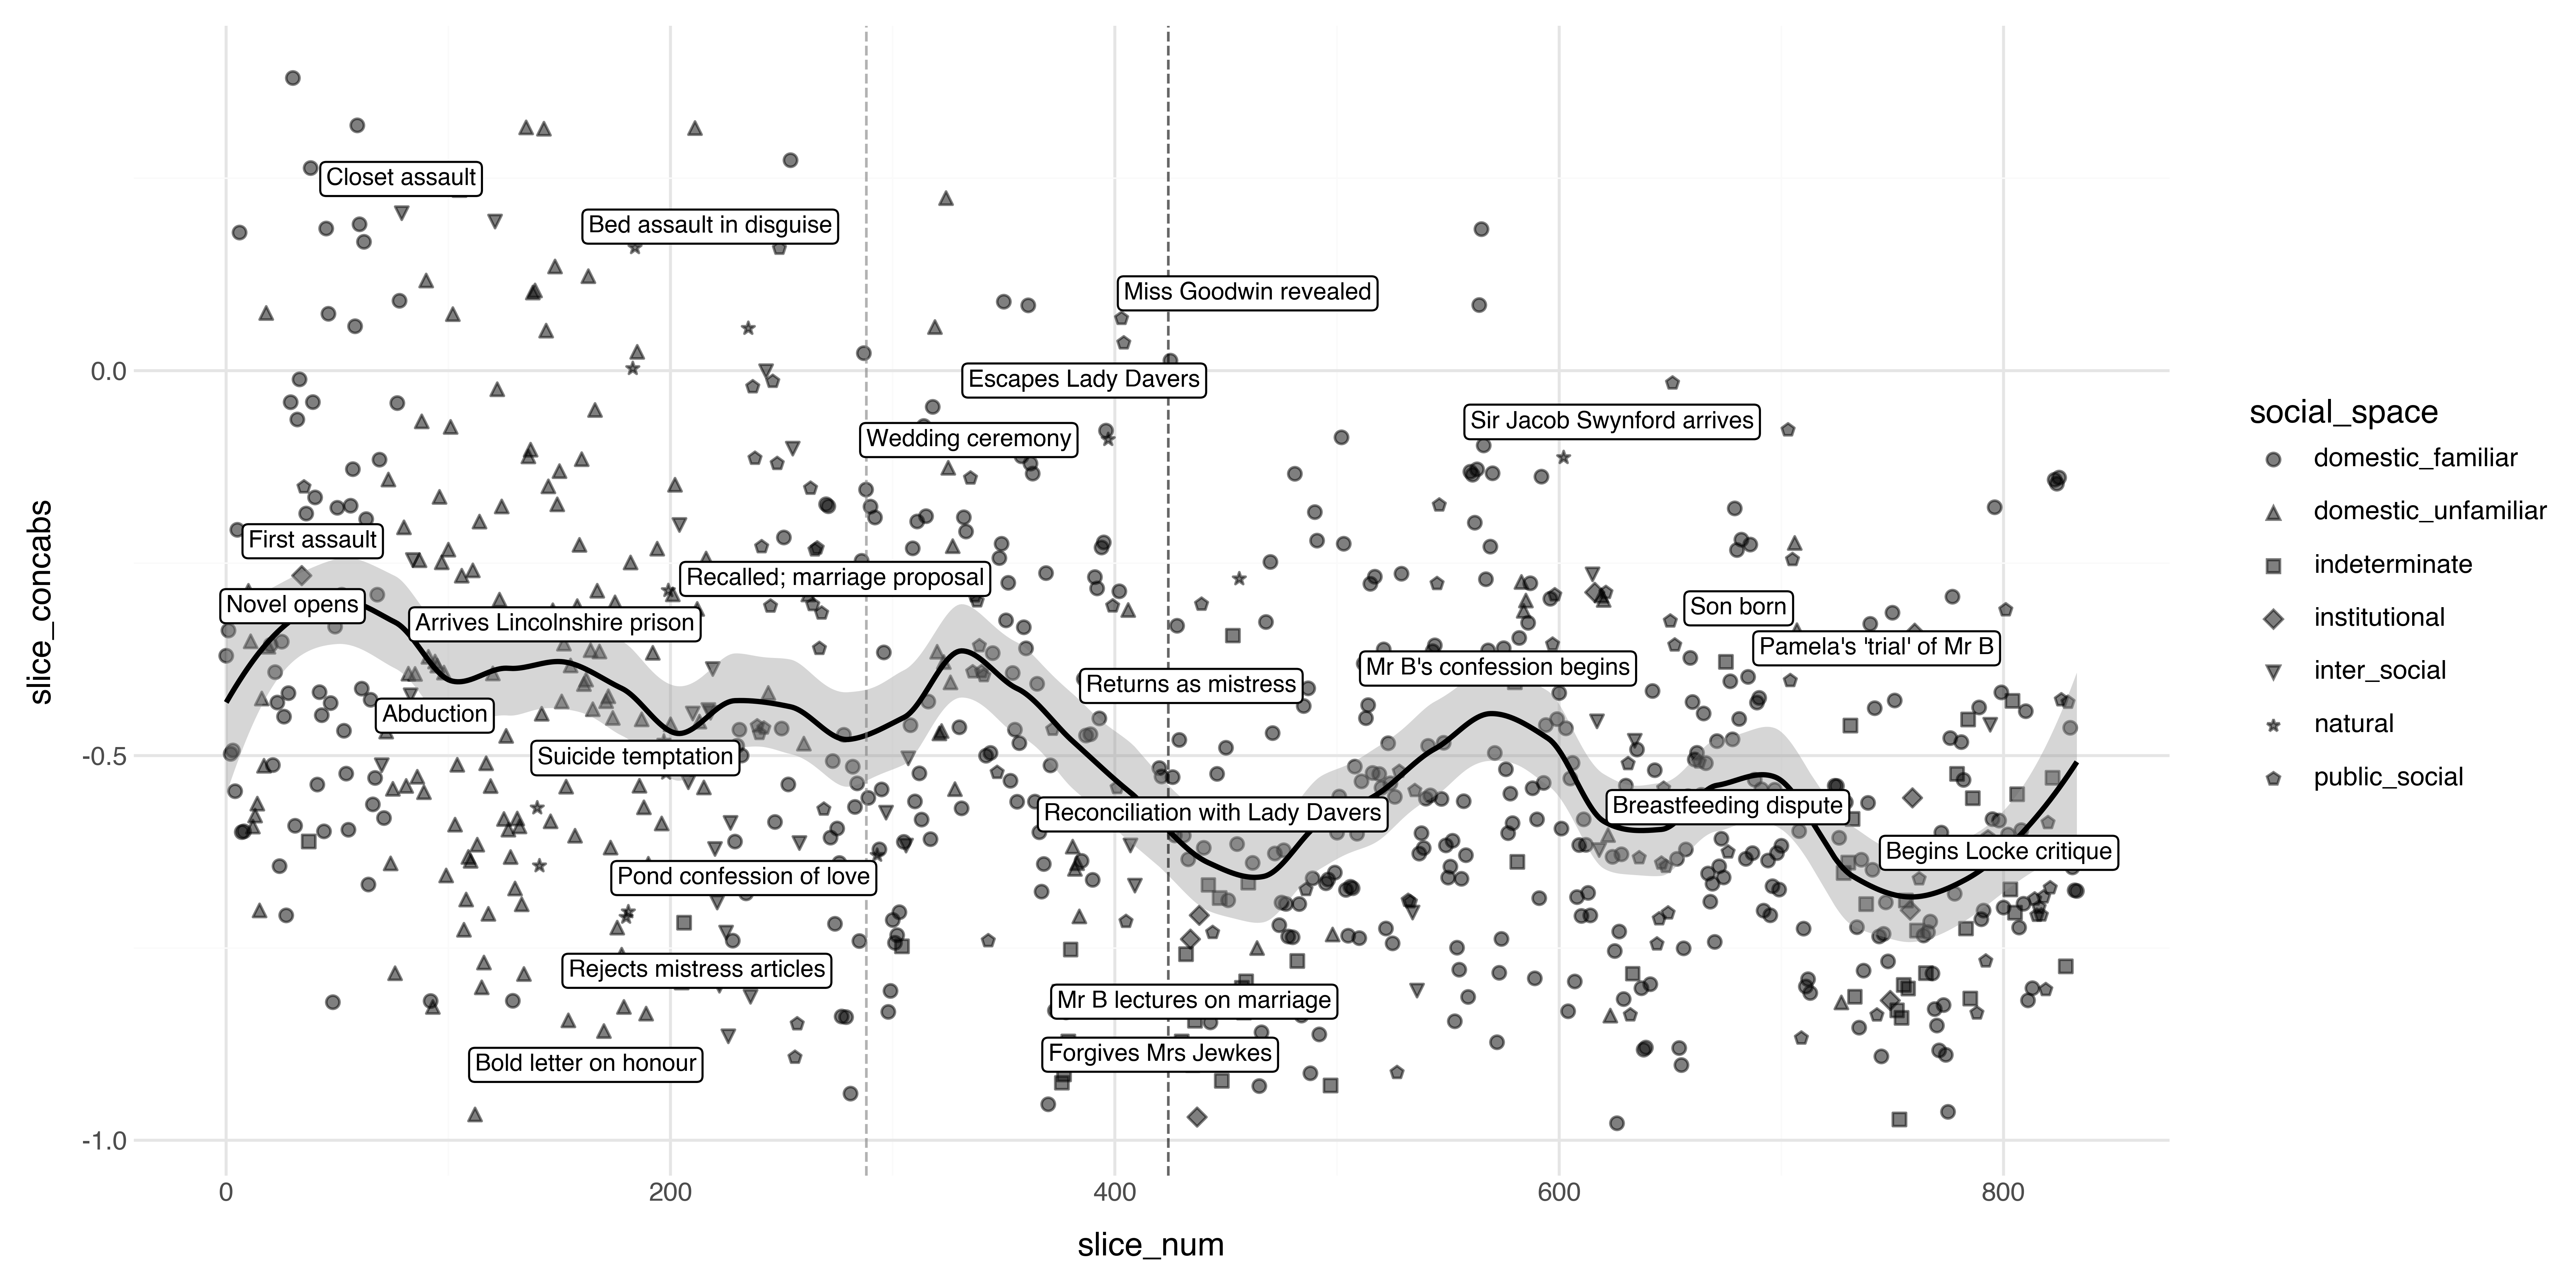

In [207]:
fig = (
    p9.ggplot(figdf, p9.aes(x='slice_num', y='slice_concabs', label='anno'))
    + p9.geom_point(p9.aes(shape='social_space'), size=2, alpha=.5)
    + p9.geom_smooth(method='loess', span=.2)
    + p9.geom_vline(
        data=figdf.query(f'slice_num == 288'),
        mapping=p9.aes(xintercept='slice_num'),
        linetype='dashed',
        color='gray',
        alpha=0.6
    )
    + p9.geom_vline(
        data=figdf.query(f'slice_num == {pamela1_slices.slice_num.max()}'),
        mapping=p9.aes(xintercept='slice_num'),
        linetype='dashed',
        color='black',
        alpha=0.6
    )
    + p9.geom_label(
        # p9.aes(color='social_space'),
        data=figdf[figdf['anno'] != ''],
        # mapping=p9.aes(x='slice_num', y=figdf['slice_concabs'].min() + 0.1, label='anno'),
        # angle=90,
        va='bottom',
        ha='left',
        size=8,
        # color='red',
        nudge_y=0.05,
        fontstyle="italic"
    )
    + p9.theme_minimal()
    + p9.theme(figure_size=(12,6), dpi=300)
    # + p9.coord_flip()
    # + p9.scale_x_reverse()
    # + p9.scale_color_gradient(low='blue', high='red')
    + p9.scale_color_gray()
)
fig


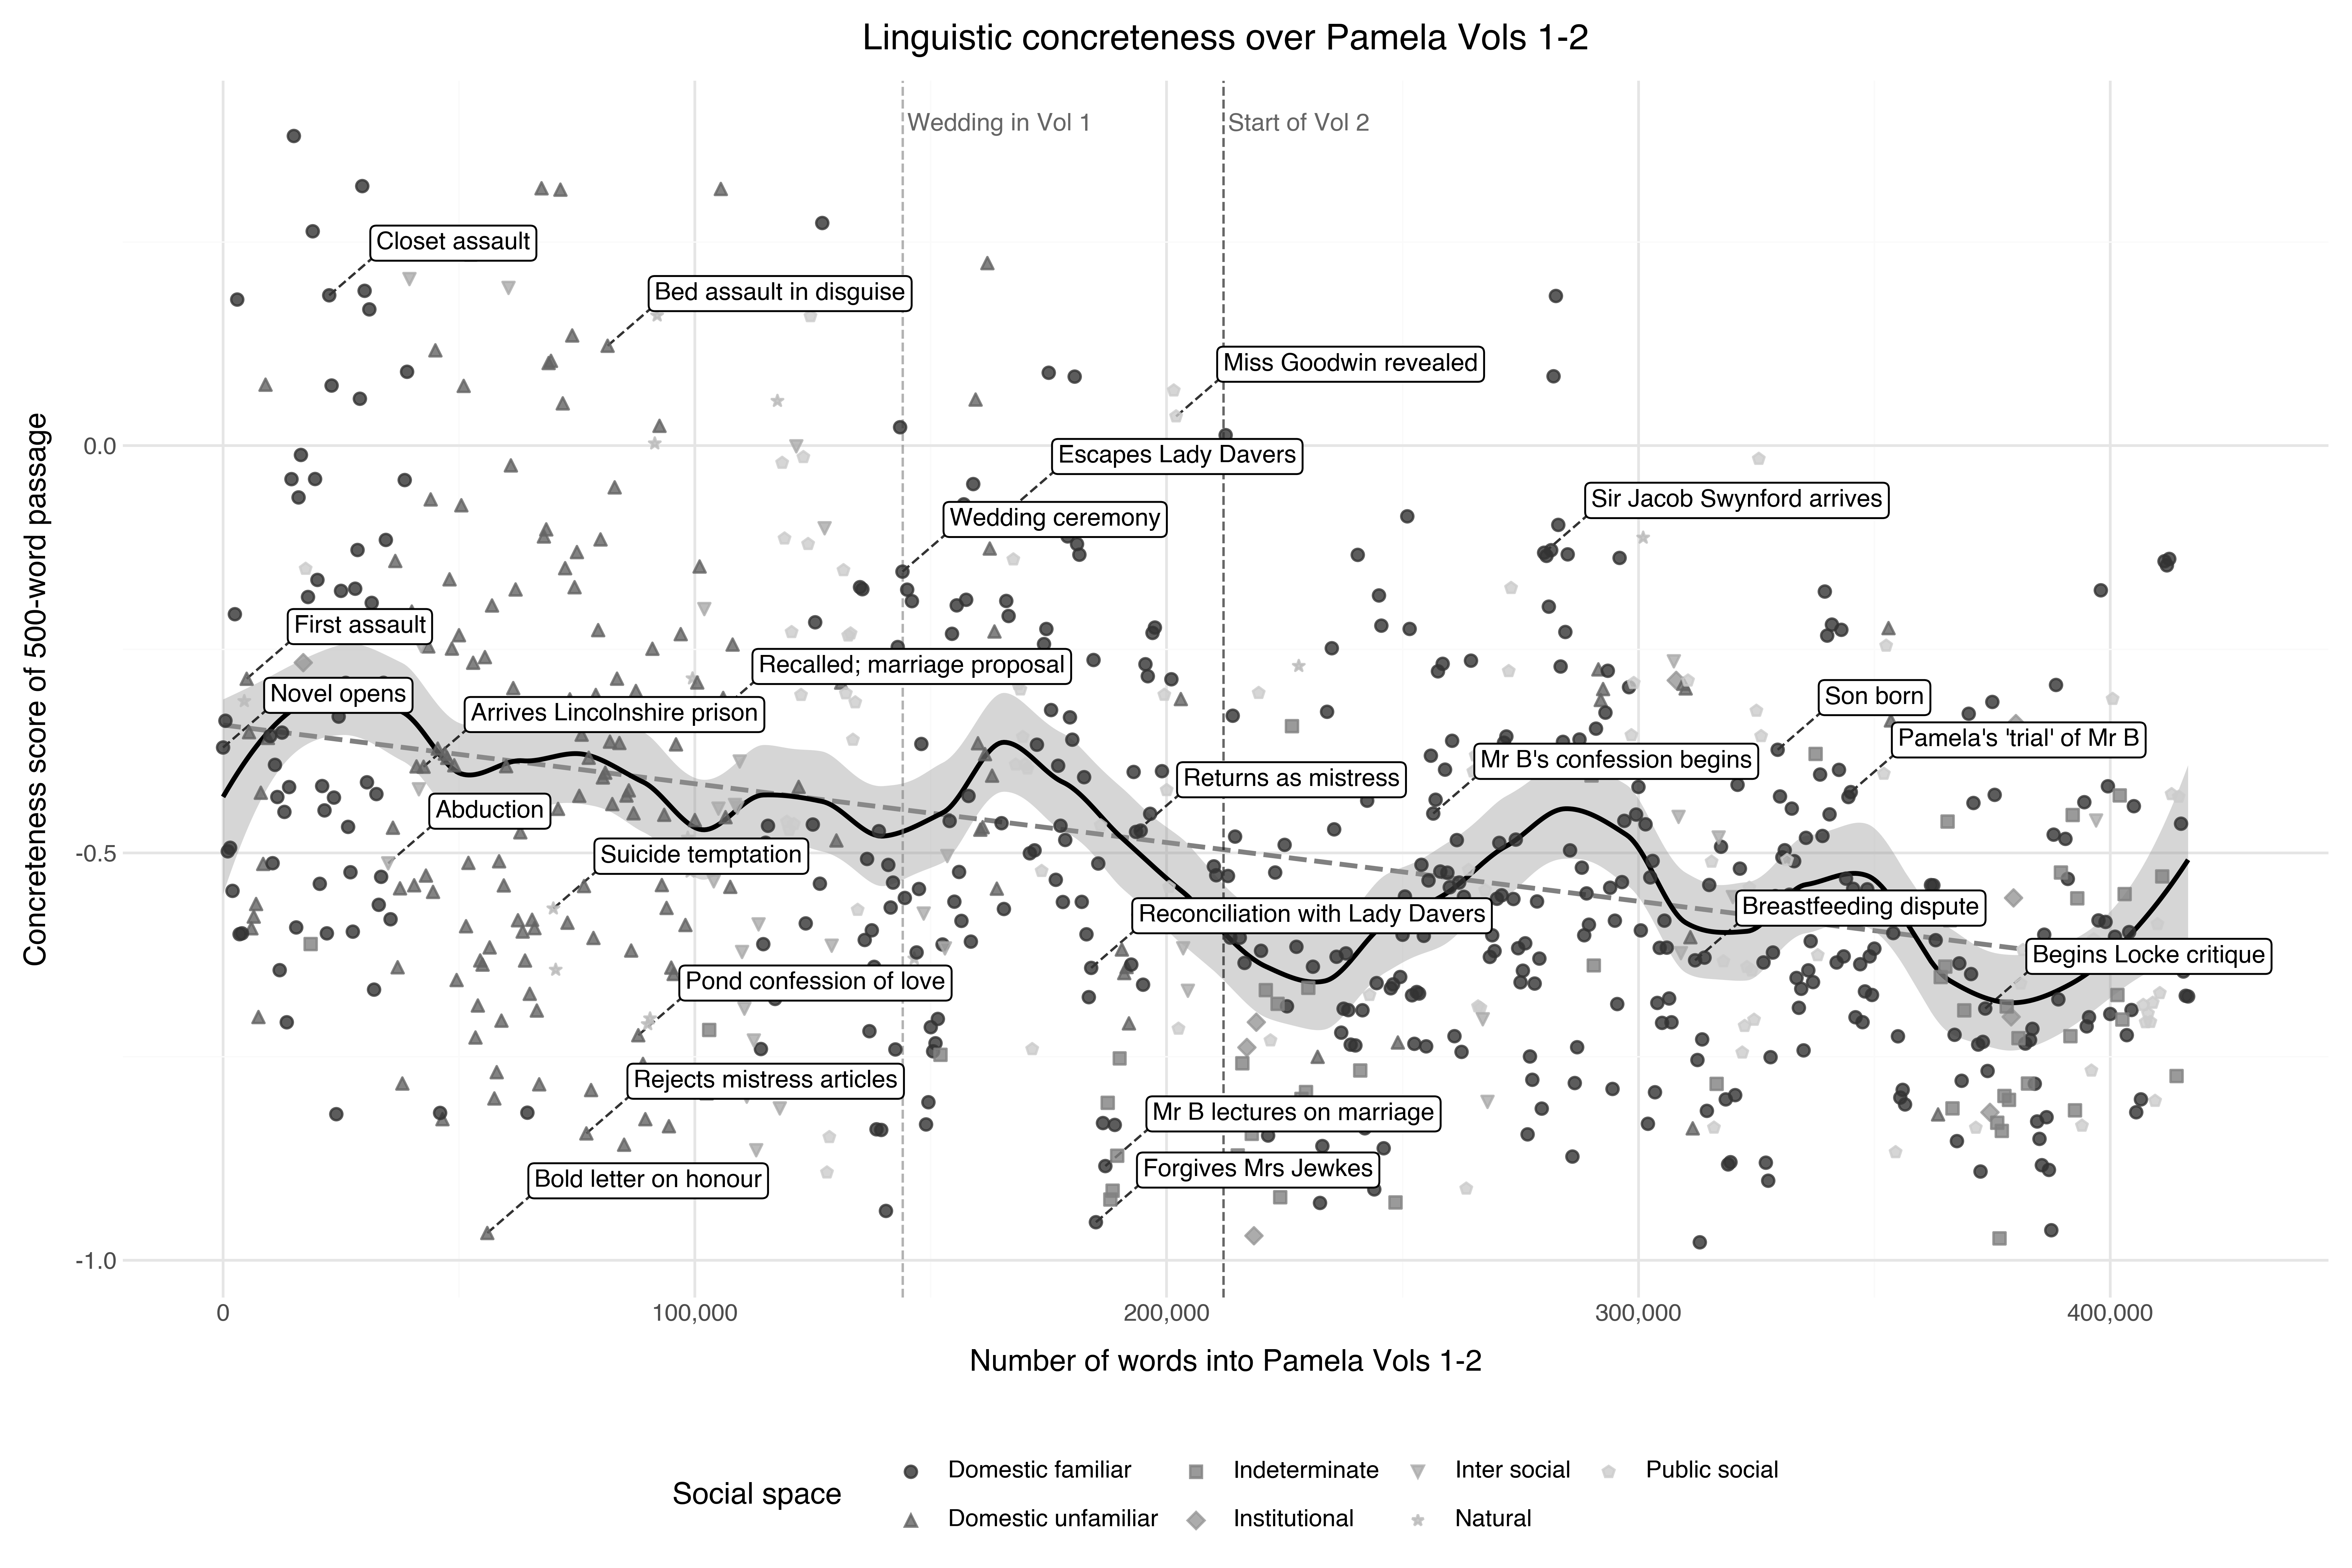

In [ ]:
labels = (
    figdf.loc[figdf["anno"] != "", ["slice_num", "slice_concabs", "anno"]]
    .assign(
        label_x=lambda d: d["slice_num"] + 20,      # horizontal nudge for label
        label_y=lambda d: d["slice_concabs"] + 0.05  # vertical nudge for label
    )
)

figdf['social_space'] = figdf['social_space'].apply(lambda x: x[0].upper() + x[1:].replace('_', ' '))

vol2_label = pd.DataFrame({
    "x": [288, pamela2_slices.slice_num.min()],
    "y": [figdf["slice_concabs"].max()] * 2,   # place near top of panel
    "label": ["Wedding in Vol 1", "Start of Vol 2"],
})

fig = (
    p9.ggplot(figdf, p9.aes(x="slice_num", y="slice_concabs", label="anno"))
    + p9.geom_smooth(method='lm', alpha=.2, linetype='dashed', color='gray', se=False)
    + p9.geom_smooth(method="loess", span=0.2)

    + p9.geom_vline(
        data=figdf.query("slice_num == 288"),
        mapping=p9.aes(xintercept="slice_num"),
        linetype="dashed",
        color="gray",
        alpha=0.6,
    )
    + p9.geom_vline(
        data=figdf.query(f"slice_num == {pamela1_slices.slice_num.max()}"),
        mapping=p9.aes(xintercept="slice_num"),
        linetype="dashed",
        color="black",
        alpha=0.6,
    )
    + p9.geom_text(
        data=vol2_label,
        mapping=p9.aes(x="x", y="y", label="label"),
        inherit_aes=False,
        ha="left",      # text starts at x=288 and goes right
        va="bottom",
        nudge_x=2,      # move slightly to the right of the line
        size=9,
        color="black",
        alpha=.6
        # fontstyle="italic"
    )

    # Arrow from anchored point -> label location
    + p9.geom_segment(
        data=labels,
        mapping=p9.aes(
            x="slice_num",
            y="slice_concabs",
            xend="label_x",
            yend="label_y",
        ),
        inherit_aes=False,
        linetype='dashed',
        color="black",
        size=0.5,
        alpha=.8,
        # arrow=p9.arrow(length=0.08, ends="last", type="closed"),
    )
    + p9.geom_point(p9.aes(shape="social_space", color="social_space"), size=2, alpha=.8)

    # Label placed at nudged location
    + p9.geom_label(
        data=labels,
        mapping=p9.aes(x="label_x", y="label_y", label="anno"),
        inherit_aes=False,
        size=9,
        fontstyle="italic",
        va="bottom",
        ha="left",
    )

    + p9.theme_minimal()
    + p9.theme(figure_size=(12, 8), dpi=300)
    + p9.scale_color_gray()
    + p9.theme(legend_position='bottom')
    + p9.scale_x_continuous(labels=lambda breaks: [f"{int(b*500):,}" for b in breaks], limits=(0, 850))
    + p9.labs(
        x='Number of words into Pamela Vols 1-2',
        y='Concreteness score of 500-word passage',
        color='Social space',
        shape='Social space',
        title='Linguistic concreteness over Pamela Vols 1-2',
        # subtitle='The dashed line shows the average concreteness of the 500-word passages in Pamela Vols 1-2',
    )
)
fig.save('../../figures/concreteness-over-pamela.png')
fig

In [133]:
pd.set_option('display.max_colwidth', None)

odf=figdf.sort_values('slice_concabs', ascending=True).head(25).set_index('slice_num')

In [135]:
print(odf.to_markdown())

|   slice_num |   slice_concabs | summary                                                                                                                                                                                                                                                                  | anno                     | pre_post_wedding   |
|------------:|----------------:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------------------|:-------------------|
|         112 |       -0.966324 | Pamela writes a bold letter to her master, questioning his definition of "honour," demanding he state his intentions plainly, and warning him of her desperation if he comes to the estate.                                                                              |  

In [131]:
odf.to_markdown??

Signature:
odf.to_markdown(
    buf: 'FilePath | WriteBuffer[str] | None' = None,
    *,
    mode: 'str' = 'wt',
    index: 'bool' = True,
    storage_options: 'StorageOptions | None' = None,
    **kwargs,
) -> 'str | None'
Docstring:
Print DataFrame in Markdown-friendly format.

Parameters
----------
buf : str, Path or StringIO-like, optional, default None
    Buffer to write to. If None, the output is returned as a string.
mode : str, optional
    Mode in which file is opened, "wt" by default.
index : bool, optional, default True
    Add index (row) labels.

storage_options : dict, optional
    Extra options that make sense for a particular storage connection, e.g.
    host, port, username, password, etc. For HTTP(S) URLs the key-value pairs
    are forwarded to ``urllib.request.Request`` as header options. For other
    URLs (e.g. starting with "s3://", and "gcs://") the key-value pairs are
    forwarded to ``fsspec.open``. Please see ``fsspec`` and ``urllib`` for more
    details, 

In [58]:
slices['meta_slice_num'] = slices['slice_num'] // 25 * 25
figdf = slices.groupby(['novel', 'meta_slice_num']).mean(numeric_only=True).reset_index()
figdf

,novel,meta_slice_num,slice_num,slice_concabs,concrete_abstract,n_char_descriptions,n_abstractions,n_concretions,co_presence
0,Anon.Lazarillo,0,12.000000,0.280371,5.560000,1.480000,6.080000,10.240000,0.582374
1,Anon.Lazarillo,25,37.000000,0.008339,4.000000,1.680000,8.080000,9.680000,0.790444
2,Anon.Lazarillo,50,59.500000,0.161228,4.950000,2.250000,7.350000,10.250000,0.725140
3,Anon.Lazarillo,75,89.500000,0.202303,5.400000,1.850000,7.700000,10.150000,0.725644
4,Anon.Lazarillo,100,100.000000,-0.206275,4.000000,2.000000,5.000000,8.000000,0.625000
5,Richardson.Pamela,0,12.000000,-0.416584,3.240000,2.640000,9.640000,8.640000,0.872444
6,Richardson.Pamela,25,37.000000,-0.269598,3.760000,3.040000,9.120000,8.120000,0.786040
7,Richardson.Pamela,50,62.000000,-0.295649,3.800000,1.840000,8.800000,7.880000,0.740079
8,Richardson.Pamela,75,87.000000,-0.351249,3.560000,2.200000,9.360000,8.960000,0.869000
9,Richardson.Pamela,100,112.000000,-0.404358,3.520000,1.960000,9.680000,9.160000,0.841879


In [ ]:
# figdf[['slice_concabs','concrete_abstract']].corr()

In [ ]:

fig = (
    p9.ggplot(figdf, p9.aes(x='meta_slice_num', y='slice_concabs', color='novel')) + 
    p9.geom_point() + 
    p9.geom_line() + 
    # p9.geom_smooth(method='loess', span=.3) + 
    p9.theme_minimal()
)
fig